In [24]:
import pandas as pd

In [42]:
df=pd.read_csv("SMSSpamCollection",sep='\t', names=['label', 'message'])

In [43]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [44]:
df.shape

(5572, 2)

In [45]:
df['message'].iloc[0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [46]:
# Convert 'spam' to 1 and 'ham' to 0 in the label column
# This will create a new column 'label_num' with the numeric values

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df[['label']].head())

   label
0      0
1      0
2      1
3      0
4      0


In [30]:
import re
import string

In [47]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs (common spam vector)
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)
    
    # Handle email addresses (spam indicator)
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    
    # Keep digits but normalize excessive repetition
    text = re.sub(r'(\d)\1{3,}', r'\1\1\1', text)  
    
    # Remove punctuation except $ and % (spam signals)
    text = re.sub(r'[^\w\s$%]', ' ', text)
    
    # Normalize currency
    text = re.sub(r'\$\s*(\d+)', r'$\1', text)  # "$ 100" → "$100"
    
    # Collapse whitespace
    text = " ".join(text.split())
    
    return text

In [48]:
df['clean_message']=df['message'].apply(clean_text)

In [56]:
df['clean_message'].iloc[2]

'free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry question std txt rate t c s apply 08452810075over18 s'

In [57]:
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True))


Class Distribution:
label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


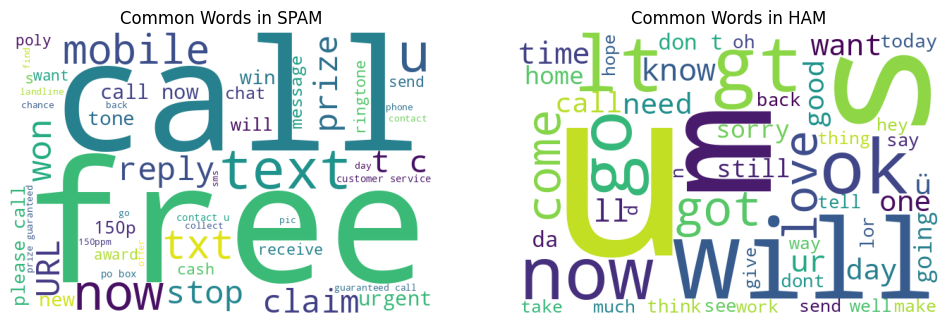

In [58]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Separate the data
spam_words = ' '.join(list(df[df['label'] == 1]['clean_message']))
ham_words = ' '.join(list(df[df['label'] == 0]['clean_message']))

# Generate Word Clouds
spam_wc = WordCloud(width=600, height=400, background_color='white', max_words=50).generate(spam_words)
ham_wc = WordCloud(width=600, height=400, background_color='white', max_words=50).generate(ham_words)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(spam_wc)
plt.title('Common Words in SPAM')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ham_wc)
plt.title('Common Words in HAM')
plt.axis('off')

plt.show()

In [36]:
!pip install gensim

In [59]:
from gensim.models.fasttext import FastText

sentences=[sentence.split() for sentence in df['clean_message']]
model = FastText(vector_size=100,window=5, min_count=2)
model.build_vocab(corpus_iterable=sentences)
model.train(corpus_iterable=sentences, total_examples=len(sentences), epochs=10)

(676621, 900460)

In [60]:
model.save("spam_fasttext_gensim.model")

print("Model saved safely!")

Model saved safely!


In [61]:
# Check words close to "free"
print("Words mathematically close to 'free':")
print(model.wv.most_similar("free", topn=5))

# Check words close to "winner"
print("\nWords mathematically close to 'winner':")
print(model.wv.most_similar("winner", topn=5))

# The OOV Test: Test a word that DOESN'T exist in the dataset (like a typo)
# Even if 'v1ctory' isn't there, FastText will find a vector for it!
print("\nVector for out-of-vocabulary word 'v1ctory':")
print(model.wv.most_similar("v1ctory", topn=3))

Words mathematically close to 'free':
[('5free', 0.9983860850334167), ('reply', 0.9951861500740051), ('txt', 0.9944707751274109), ('ctxt', 0.9938575625419617), ('claim', 0.9937118291854858)]

Words mathematically close to 'winner':
[('continue', 0.998976469039917), ('control', 0.9987854957580566), ('ref', 0.9987726211547852), ('holder', 0.9986000657081604), ('xxxx', 0.9985287189483643)]

Vector for out-of-vocabulary word 'v1ctory':
[('luxury', 0.999480664730072), ('magical', 0.9992446303367615), ('desperate', 0.9992204308509827)]


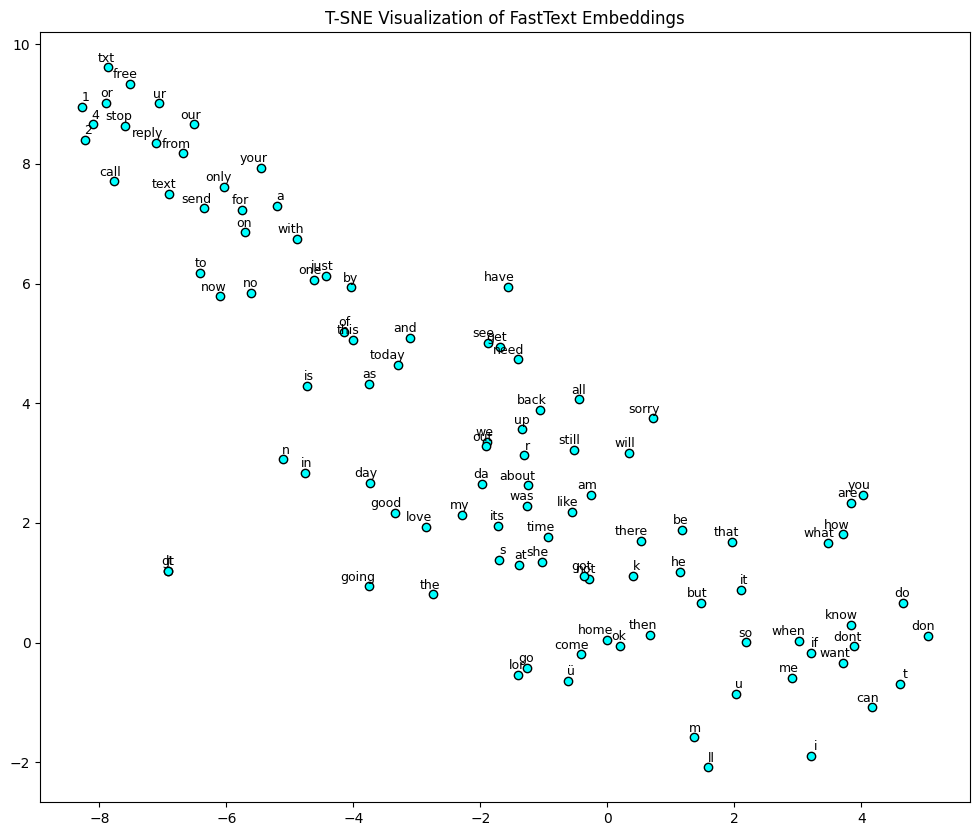

In [62]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Pick the words you want to visualize (Top 100 most frequent)
words = list(model.wv.index_to_key)[:100]
word_vectors = np.array([model.wv[word] for word in words])

# 2. Run T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(word_vectors)

# 3. Plot the results
plt.figure(figsize=(12, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='cyan')

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom', fontsize=9)

plt.title('T-SNE Visualization of FastText Embeddings')
plt.show()

In [41]:
%ls

sample_data/       spam_fasttext_gensim.model
SMSSpamCollection  spam_fasttext_gensim.model.wv.vectors_ngrams.npy
